

> Add blockquote# 🚢 Titanic Survival Prediction Using Machine Learning

### CodSoft Data Science Internship

**Project:** Titanic Survival Prediction  
**Domain:** Data Science / Machine Learning  
**Model:** Logistic Regression  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn



# 📑 Table of Contents

1. Introduction
2. Objective
3. Technologies and Libraries Used
4. Dataset Description
5. Import Libraries
6. Load Dataset
7. Dataset Exploration
8. Data Cleaning
9. Exploratory Data Analysis
10. Feature Selection
11. Train/Test Split
12. Data Preprocessing
13. Model Training
14. Making Predictions
15. Model Accuracy
16. Classification Report
17. Confusion Matrix
18. Feature Importance
19. New Passenger Prediction
20. Conclusion
21. Future Scope

## 1. Introduction

The Titanic Survival Prediction project is a Machine Learning classification project that aims to predict whether a passenger survived the Titanic disaster based on information such as passenger class, gender, age, number of siblings or spouses, number of parents or children, fare, and port of embarkation.

In this project, the Titanic dataset is loaded and explored using Python. Data cleaning and preprocessing techniques are applied to handle missing values and categorical data.

A Logistic Regression Machine Learning model is trained using the prepared dataset. The model is then evaluated using accuracy, a classification report, and a confusion matrix.

Finally, the trained model is used to predict the survival status of a new passenger.

## 2. Objective

The main objectives of this project are:

1. To understand and explore the Titanic dataset.
2. To identify the important features related to passenger survival.
3. To handle missing values in the dataset.
4. To convert categorical data into a suitable numerical format.
5. To divide the dataset into training and testing data.
6. To train a Machine Learning classification model.
7. To evaluate the performance of the model.
8. To visualize the model results.
9. To predict the survival status of a new passenger.

## 3. Technologies and Libraries Used

### Programming Language
- Python

### Platform
- Google Colab

### Libraries
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Machine Learning Algorithm
- Logistic Regression

## 4. Dataset Description

The Titanic dataset contains information about passengers who travelled on the RMS Titanic.

The target variable is:

- **Survived = 0:** Passenger did not survive
- **Survived = 1:** Passenger survived

Important features include:

- Passenger class
- Sex
- Age
- Number of siblings/spouses aboard
- Number of parents/children aboard
- Passenger fare
- Port of embarkation

The dataset is commonly used for learning classification and data analysis techniques.

## 5. Import Libraries

The required Python libraries are imported for data manipulation, visualization, preprocessing, model training, and evaluation.

In [352]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 6. Load Dataset

The Titanic dataset is loaded using the Seaborn library.

In [353]:
df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully!")

Titanic dataset loaded successfully!


In [354]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 7. Dataset Exploration

In this step, the dataset is explored to understand its structure, number of records, columns, data types, and missing values.

In [355]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 15


In [356]:
print("Column names:")
print(df.columns.tolist())

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [357]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [358]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [359]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## 8. Data Cleaning

The Titanic dataset contains missing values in some columns. Missing values can affect the performance of a Machine Learning model.

In this project, missing numerical values are handled using the median value, while missing categorical values are handled using the most frequent value.

The preprocessing steps are applied through a Scikit-learn Pipeline.

In [360]:
missing_values = df.isnull().sum()

print("Missing values before preprocessing:")
print(missing_values[missing_values > 0])

Missing values before preprocessing:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


## 9. Exploratory Data Analysis

Exploratory Data Analysis helps us understand patterns and relationships in the Titanic dataset.

Different visualizations are used to examine survival based on gender, passenger class, and age.

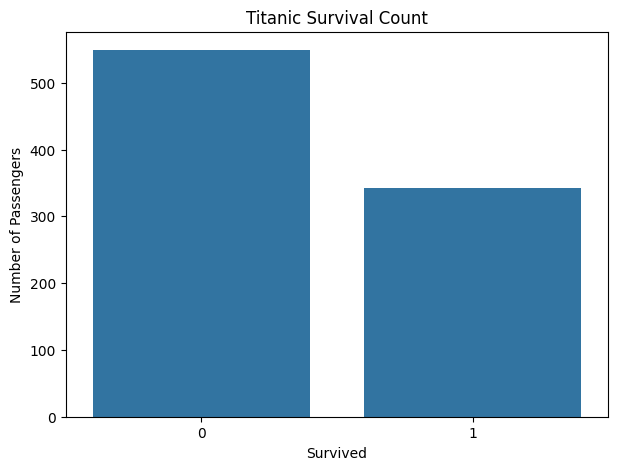

In [361]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="survived")

plt.title("Titanic Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

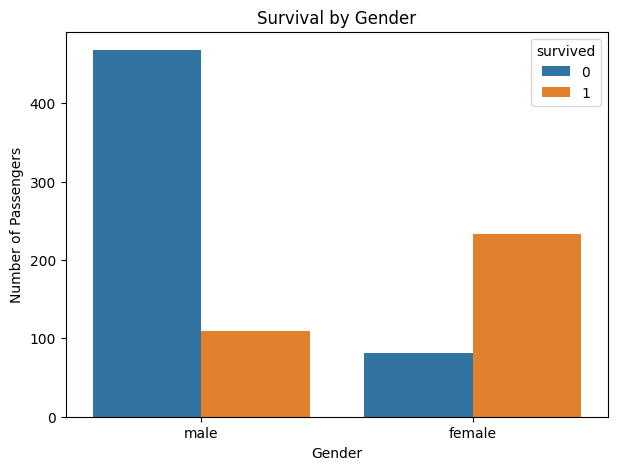

In [362]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="sex", hue="survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

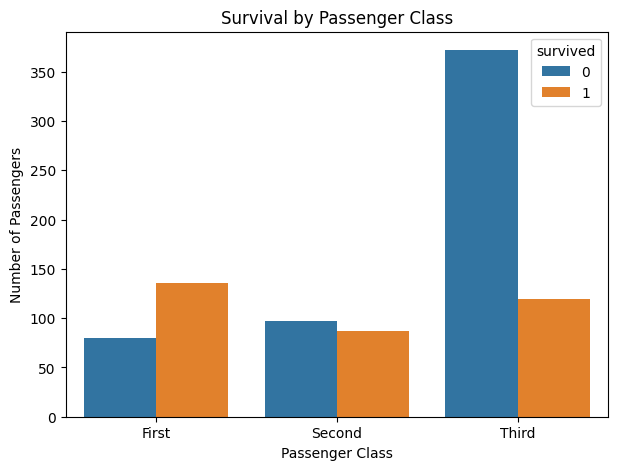

In [363]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="class", hue="survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

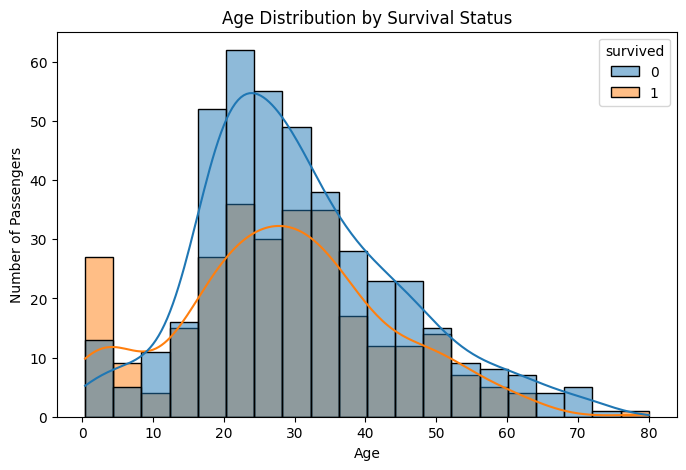

In [364]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="survived",
    kde=True
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

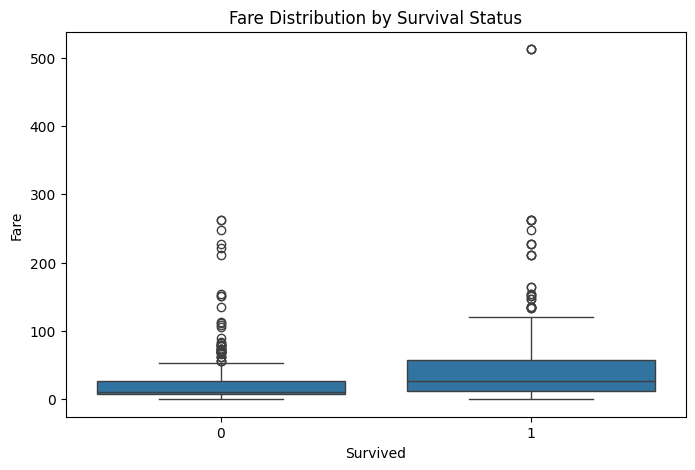

In [365]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

## 10. Feature Selection

The features selected for the Machine Learning model are:

- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked

The target variable is:

- Survived

The target variable represents whether a passenger survived the Titanic disaster.

In [366]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]
y = df["survived"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   pclass     sex   age  sibsp  parch     fare embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S

Target:
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


## 11. Train/Test Split

The dataset is divided into training and testing data.

- 80% of the data is used for training.
- 20% of the data is used for testing.

The training data is used to train the Machine Learning model, while the testing data is used to evaluate its performance on unseen data.

In [367]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 712
Testing samples: 179


## 12. Data Preprocessing

The Titanic dataset contains both numerical and categorical features.

Numerical features:

- Age
- SibSp
- Parch
- Fare
- Pclass

Categorical features:

- Sex
- Embarked

Missing numerical values are replaced using the median value.

Missing categorical values are replaced using the most frequent value.

Categorical variables are converted into numerical form using One-Hot Encoding.

In [368]:
numerical_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 13. Model Training

Logistic Regression is used as the Machine Learning classification algorithm.

The preprocessing steps and Logistic Regression model are combined into a single Pipeline.

The model learns patterns from the training data and uses these patterns to predict whether a passenger survived.

In [369]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 14. Making Predictions

The trained Machine Learning model is used to predict the survival status of passengers in the test dataset.

In [370]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 1 0 1 1
 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0
 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 0]


## 15. Model Accuracy

Accuracy represents the percentage of test samples that were correctly classified by the Machine Learning model.

In [371]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.8044692737430168
Accuracy Percentage: 80.44692737430168 %


## 16. Classification Report

The classification report provides the following evaluation metrics:

- Precision
- Recall
- F1-score
- Support

These metrics provide more detailed information about the model's classification performance.

In [372]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Did Not Survive", "Survived"]
    )
)

                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



## 17. Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the classification model.

It helps visualize how well the model distinguishes between passengers who survived and passengers who did not survive.

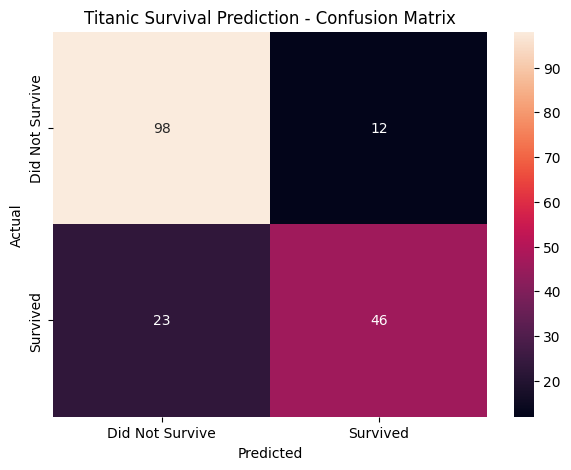

In [373]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Titanic Survival Prediction - Confusion Matrix")

plt.show()

## 18. Feature Importance

Logistic Regression assigns coefficients to the processed features.

The coefficients provide an indication of how each processed feature is associated with the model's prediction.

Positive and negative coefficients should be interpreted as model associations, not as proof that a feature directly caused survival or non-survival.

In [374]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
6,cat__sex_male,-1.311259,1.311259
5,cat__sex_female,1.307330,1.307330
0,num__pclass,-1.100016,1.100016
9,cat__embarked_S,-0.349524,0.349524
8,cat__embarked_Q,0.308588,0.308588
2,num__sibsp,-0.247910,0.247910
3,num__parch,-0.080364,0.080364
1,num__age,-0.038930,0.038930
7,cat__embarked_C,0.037007,0.037007
4,num__fare,0.002209,0.002209


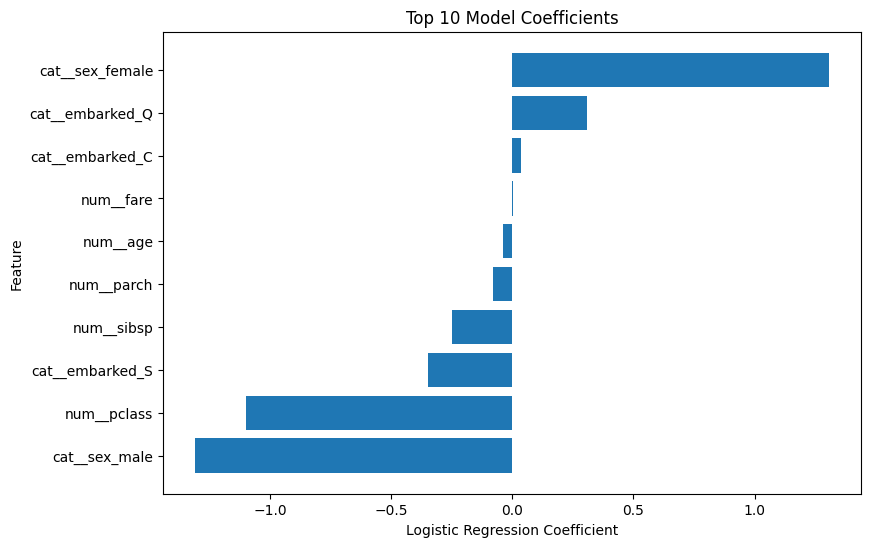

In [375]:
top_features = feature_importance.head(10).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Model Coefficients")

plt.show()

## 19. Predicting a New Passenger

The trained Machine Learning model is tested with information representing a new passenger.

The example passenger has:

- Passenger Class = 3
- Sex = Male
- Age = 25
- Siblings/Spouses = 0
- Parents/Children = 0
- Fare = 7.25
- Port = Southampton

In [376]:
new_passenger = pd.DataFrame({
    "pclass": [3],
    "sex": ["male"],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [7.25],
    "embarked": ["S"]
})

prediction = model.predict(new_passenger)[0]

if prediction == 1:
    print("Predicted Survival Status: Survived")
else:
    print("Predicted Survival Status: Did Not Survive")

Predicted Survival Status: Did Not Survive


### Prediction Probability

The model can also provide the estimated probability assigned to each survival class for the new passenger.

In [377]:
probability = model.predict_proba(new_passenger)[0]

print("Probability of Not Surviving:", probability[0])
print("Probability of Surviving:", probability[1])

Probability of Not Surviving: 0.8997009752219421
Probability of Surviving: 0.10029902477805783


## 20. Conclusion

In this project, a Machine Learning model was developed to predict passenger survival using the Titanic dataset.

The dataset was explored using Python and Pandas, and different visualizations were created using Matplotlib and Seaborn.

Data preprocessing techniques were applied to handle missing values and convert categorical variables into numerical representations.

A Logistic Regression model was trained using the processed training data. The model was evaluated using accuracy, classification report, and confusion matrix.

The model was also used to predict the survival status of a new passenger.

This project provided practical understanding of an end-to-end Machine Learning workflow, including data loading, data exploration, data cleaning, visualization, feature selection, preprocessing, model training, prediction, and evaluation.

## 21. Future Scope

This project can be further improved by:

- Comparing multiple Machine Learning algorithms.
- Testing Decision Tree and Random Forest models.
- Using K-Nearest Neighbors for comparison.
- Applying cross-validation.
- Performing hyperparameter tuning.
- Creating a user-friendly web application for predictions.
- Deploying the Machine Learning model as an online application.